In [1]:
import tiktoken

In [2]:
tokenizer=tiktoken.encoding_for_model("gpt-4o")

In [3]:
prompt="vous etes un experte en IA agentique"

In [4]:
tokens=tokenizer.encode(prompt)

In [5]:
tokens= tokenizer.encode(prompt)


In [6]:
print(len(tokens))

10


In [7]:
for token in tokens:
    t =tokenizer.decode_single_token_bytes(token).decode("utf-8")
    print(t,end="|")

vous| et|es| un| exper|te| en| IA| agent|ique|

In [8]:
from langchain_openai import ChatOpenAI
from dotenv.ipython import load_dotenv
load_dotenv(override=True)




c:\Users\hp\Documents\HESTIM 1\TP AGENTIC\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [9]:
llm = ChatOpenAI(model="gpt-4o",temperature=0)

In [19]:
response = llm.invoke(
    [
        {"role": "system", "content": "you are a helpful assistant. the output should be in markdown"},
        {"role": "user", "content": "c'est quoi l'enset"}
    ]
)

In [11]:
from IPython.display import Markdown

In [20]:
print(display(Markdown(response.content)))

L'enset, également connu sous le nom de "faux bananier" ou "bananier d'Abyssinie", est une plante appartenant au genre *Ensete*, qui fait partie de la famille des Musaceae, la même famille que celle des bananiers. L'espèce la plus connue est *Ensete ventricosum*. 

L'enset est principalement cultivé en Éthiopie, où il joue un rôle crucial dans l'alimentation et la culture des populations locales. Contrairement au bananier, l'enset n'est pas cultivé pour ses fruits, qui ne sont pas comestibles, mais pour ses parties souterraines et son pseudo-tronc. Les parties comestibles de la plante sont transformées en une pâte fermentée appelée "kocho", qui est une source importante de glucides.

La plante est également utilisée pour d'autres fins, telles que la fabrication de fibres pour des cordes et des matériaux de construction. L'enset est très résilient et peut être cultivé dans des conditions difficiles, ce qui en fait une culture de sécurité alimentaire essentielle dans certaines régions.

None


In [13]:
from langchain_ollama import ChatOllama

In [21]:
llm2 = ChatOllama(model="qwen3.5:cloud")

In [22]:
response = llm2.invoke(
    [
        {"role": "system", "content": "you are a helpful assistant. the output should be in markdown"},
        {"role": "user", "content": "c'est quoi l'enset"}
    ]
)

In [24]:
print(display(Markdown(response.content)))

# C'est quoi l'ENSET ?

Le terme **ENSET** peut faire référence à deux concepts très différents selon le contexte. Voici les deux significations principales :

## 1. Dans le domaine de l'Éducation (Sigle)
**ENSET** est l'acronyme de **École Normale Supérieure de l'Enseignement Technique**. Il s'agit de grandes écoles d'ingénieurs et de formation de professeurs. On en trouve principalement en Afrique du Nord :

*   **Au Maroc :** L'ENSET de Rabat (rattachée à l'Université Mohammed V). Elle forme des professeurs de l'enseignement technique et des ingénieurs d'État.
*   **En Tunisie :** L'ENSET de Tunis. Elle a pour mission la formation des professeurs de l'enseignement technique et la recherche dans ce domaine.
*   **En France (Historique) :** L'ancienne **ENSET de Cachan** est devenue l'**ENS Paris-Saclay**. C'était une école prestigieuse formant des agrégés et des chercheurs.

## 2. Dans le domaine de l'Agriculture et la Botanique (Nom commun)
L'**enset** (souvent écrit en minuscules) désigne une plante spécifique :

*   **Nom scientifique :** *Ensete ventricosum*.
*   **Nom commun :** Faux bananier.
*   **Origine :** Principalement cultivé en **Éthiopie**.
*   **Utilité :** C'est une plante vitale pour des millions de personnes. Bien qu'elle ressemble au bananier, ses fruits ne sont généralement pas comestibles. On consomme la pulpe de la tige et du bulbe (fermentée pour faire du *kocho*), ainsi que les fibres pour des usages textiles ou de construction.
*   **Importance :** Elle est souvent surnommée "l'arbre contre la faim" car elle résiste bien à la sécheresse.

---

### En résumé
*   Si vous parlez d'**études, d'école ou d'ingénierie** (surtout au Maghreb), il s'agit de l'**École Normale**.
*   Si vous parlez de **botanique, d'Afrique de l'Est ou d'alimentation**, il s'agit de la **plante (faux bananier)**.

Dans quel contexte avez-vous rencontré ce terme ?

None


In [16]:
  from langchain_groq import ChatGroq

In [27]:
llm3 =ChatGroq(model="openai/gpt-oss-120b")

In [29]:
response = llm3.invoke(
    [
        {"role": "system", "content": "you are a helpful assistant. the output should be in markdown"},
        {"role": "user", "content": "c'est quoi l'enset"}
    ]
) 

In [34]:
llm4 = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm4.bind_tools([
    {
        "type": "image_generation",
        "quality": "high"
    }
])

In [36]:
from langchain.messages import SystemMessage ,HumanMessage,AIMessage

In [45]:
resp = llm_with_tools.invoke([
    SystemMessage(""),
    HumanMessage(content="je veux une image de Neymar junior da silva au brasil ")
])

In [42]:
from IPython.display import Image
import base64


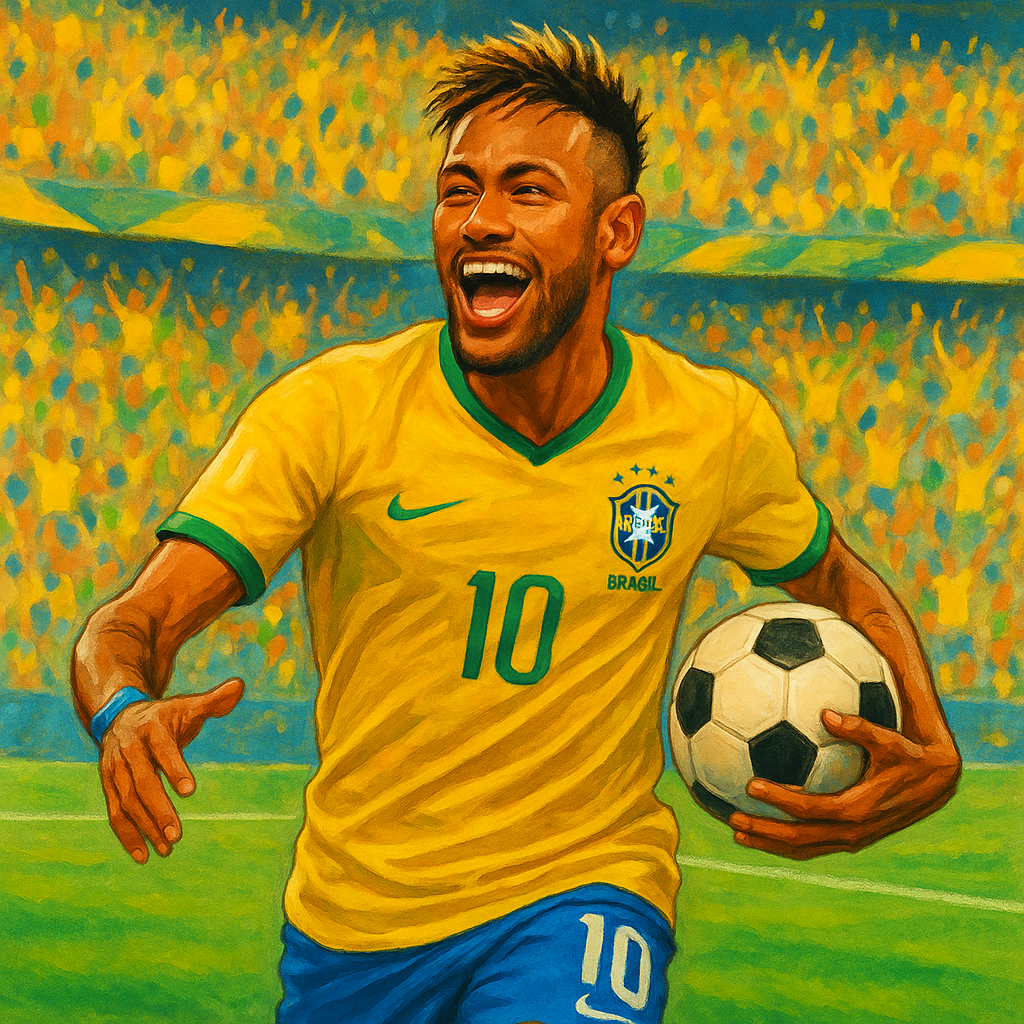

In [47]:
Image(base64.b64decode(resp.content_blocks[0]['base64'] ))

In [54]:
llm5 = ChatOpenAI(model="gpt-5.2"
                  )

In [60]:
path = '2018965.jpg' 

with open(path, 'rb') as file:
    img = base64.b64encode(file.read()).decode('utf-8')

In [62]:
resp = llm5.invoke([
    HumanMessage(content=[
        {
            "type": "text",
            "text": "Explique-moi ce qu'il y a dans l'image"
        },
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{img}"
            }
        }
    ])
])

In [64]:
print (display(Markdown(resp.content)))

L’image montre une représentation stylisée d’un **microprocesseur / puce électronique** posé sur une **carte de circuit imprimé**.

- Au centre, on voit un **bloc carré** lumineux bleu, comme un **chip** (le “cœur” de calcul d’un ordinateur).
- Sur sa surface, on distingue des **motifs de pistes et de connexions** qui évoquent les circuits internes.
- En dessous et autour, la carte mère (PCB) affiche un réseau de **pistes conductrices** qui partent dans différentes directions, reliant la puce aux autres composants.
- L’effet de **lueur bleue** et de transparence est surtout graphique/illustratif, pour symboliser la puissance de calcul, l’électronique ou l’IA, plutôt qu’une photo réaliste.

None


In [70]:
system_message = """
vous etre un expert dans l 'analyse des sentiments.
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, keybloard et pad.
Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keybloard, pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect. Organisez votre réponse dans un objet JSON avec les en-têtes suivants :
  - category:[liste des aspects]
  - polarity:[liste des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre 
"""

In [67]:
llm6 =ChatOpenAI(model="gpt-5.2")

In [71]:
from langchain_core.messages import SystemMessage, HumanMessage

resp = llm6.invoke(input=[
    SystemMessage(content=system_message),
    HumanMessage(content="j'ai beaucoup aimé l'écran. La souris n'est pas bonne et le clavier m'a un peu dérangé.")
])

In [73]:
print(resp.content )

```json
{
  "category": ["screen", "keybloard", "pad"],
  "polarity": ["positive", "negative", "negative"]
}
```


In [74]:
import json

In [79]:
sentiment =json.loads(resp.content.replace("```json","").replace("```"," ")
)

In [81]:
print(sentiment)

{'category': ['screen', 'keybloard', 'pad'], 'polarity': ['positive', 'negative', 'negative']}


In [84]:
print(sentiment['category'])

['screen', 'keybloard', 'pad']


In [86]:
print(sentiment['polarity'])

['positive', 'negative', 'negative']


In [87]:
print(sentiment['category'][0])

screen
